In [155]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

In [110]:
df = pd.read_csv("/Users/raghav/Downloads/Company Names.csv")

In [111]:
df.head()

,Company Name,Rating,Review Count,Company Type,Headquarters,Company Age,Number of Employees
0,TCS,3.9,16.1k Reviews,Public,Mumbai + 156 more,52 years old,10000+ employees
1,Accenture,4.0,13.9k Reviews,Private,Dublin + 40 more,31 years old,10000+ employees
2,ICICI Bank,4.1,12.6k Reviews,Public,Mumbai + 42 more,26 years old,10000+ employees
3,Cognizant,3.9,12k Reviews,Private,Teaneck + 39 more,26 years old,10000+ employees
4,HDFC Bank,4.0,10.8k Reviews,Public,Mumbai + 46 more,26 years old,10000+ employees


In [112]:
names = list(df["Company Name"])
names[:5]

['TCS', 'Accenture', 'ICICI Bank', 'Cognizant', 'HDFC Bank']

In [113]:
names = [name.lower() for name in names]
names = [''.join(c for c in name if c.isalpha() or c == ' ') for name in names]
names = [name.strip() for name in names]
names = [name for name in names if name]

In [114]:
chars = sorted(list(set(''.join(names))))
chars

[' ',
 'a',
 'b',
 'c',
 'd',
 'e',
 'f',
 'g',
 'h',
 'i',
 'j',
 'k',
 'l',
 'm',
 'n',
 'o',
 'p',
 'q',
 'r',
 's',
 't',
 'u',
 'v',
 'w',
 'x',
 'y',
 'z',
 'ä',
 'é',
 'í',
 'ü',
 'ā',
 'š']

In [115]:
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['~'] = 0
stoi 

{' ': 1,
 'a': 2,
 'b': 3,
 'c': 4,
 'd': 5,
 'e': 6,
 'f': 7,
 'g': 8,
 'h': 9,
 'i': 10,
 'j': 11,
 'k': 12,
 'l': 13,
 'm': 14,
 'n': 15,
 'o': 16,
 'p': 17,
 'q': 18,
 'r': 19,
 's': 20,
 't': 21,
 'u': 22,
 'v': 23,
 'w': 24,
 'x': 25,
 'y': 26,
 'z': 27,
 'ä': 28,
 'é': 29,
 'í': 30,
 'ü': 31,
 'ā': 32,
 'š': 33,
 '~': 0}

In [116]:
itos = {i:s for s,i in stoi.items()}
itos

{1: ' ',
 2: 'a',
 3: 'b',
 4: 'c',
 5: 'd',
 6: 'e',
 7: 'f',
 8: 'g',
 9: 'h',
 10: 'i',
 11: 'j',
 12: 'k',
 13: 'l',
 14: 'm',
 15: 'n',
 16: 'o',
 17: 'p',
 18: 'q',
 19: 'r',
 20: 's',
 21: 't',
 22: 'u',
 23: 'v',
 24: 'w',
 25: 'x',
 26: 'y',
 27: 'z',
 28: 'ä',
 29: 'é',
 30: 'í',
 31: 'ü',
 32: 'ā',
 33: 'š',
 0: '~'}

In [117]:
vocab_size = len(stoi)
vocab_size

34

In [118]:
n_embd = 10

In [119]:
C = torch.randn(vocab_size,n_embd)
C

tensor([[ 1.7340, -0.3324, -1.9819, -1.4036,  0.5564,  0.2798,  0.1679,  0.7519,
         -0.2169,  1.3418],
        [-1.5058,  0.2840,  0.7118,  2.0604, -2.4413, -1.5378, -1.0916, -0.0897,
         -0.8376, -0.6651],
        [ 0.6175,  0.4102,  0.2022, -0.4502, -1.2284,  0.9144,  1.2747,  0.3024,
         -0.1165,  0.4459],
        [ 0.2916,  0.6487, -1.4177,  0.5744,  0.4217, -0.3929,  0.4245,  0.8183,
          0.2703, -1.2790],
        [ 0.6300, -0.2037, -0.2172,  0.3509,  0.0595,  0.1164, -1.8214, -0.8960,
         -0.8646,  0.8655],
        [ 2.0148, -0.4993,  1.0986, -0.0925, -0.3512,  0.7034, -1.1810,  1.3638,
          0.1161,  0.2044],
        [ 0.7076, -0.3975,  1.5757,  0.4888, -1.1685, -0.1513,  0.8670,  1.3998,
          0.9350, -0.6866],
        [-0.5068,  0.2870,  0.2494,  1.1936,  0.0089,  1.4846, -2.1146, -0.9032,
         -2.3284,  0.1819],
        [ 0.7851, -1.4129,  0.1279, -2.7671,  0.7023,  1.9252, -0.5830,  0.0078,
         -2.0962,  1.2097],
        [-0.1539, -

In [120]:
context_size = 3
X = []
Y = []

for name in names:
    context = [0] * context_size
    for ch in name + '~':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix]
        
X = torch.tensor(X)
Y = torch.tensor(Y)

In [121]:
X.shape, Y.shape

(torch.Size([173609, 3]), torch.Size([173609]))

In [122]:
X

tensor([[ 0,  0,  0],
        [ 0,  0, 21],
        [ 0, 21,  4],
        ...,
        [10, 15, 16],
        [15, 16, 10],
        [16, 10, 20]])

In [123]:
C.shape

torch.Size([34, 10])

In [124]:
C[X].shape

torch.Size([173609, 3, 10])

In [125]:
emb = C[X]
emb = emb.view(X.shape[0],-1)
emb.shape

torch.Size([173609, 30])

In [146]:
n_hidden = 100
W1 = torch.randn((n_embd*context_size),n_hidden)
b1 = torch.randn(n_hidden)
W2 = torch.randn(n_hidden,vocab_size)
b2 = torch.randn(vocab_size)

parameters = [C,W1,b1,W2,b2]

In [147]:
for p in parameters:
    p.requires_grad = True

In [149]:
sum(p.nelement() for p in parameters)

6874

In [152]:
step_size = 1000

for i in range(step_size):
    emb = C[X]
    emb = emb.view(X.shape[0],-1)
    hpre = emb @ W1 + b1
    h = torch.tanh(hpre)
    logits = h @ W2 + b2

    loss = F.cross_entropy(logits,Y)

    if i % 100 == 0:
        print(loss.item())

    for p in parameters:
        p.grad = None

    loss.backward()

    lr = 0.1

    for p in parameters:
        p.data += -lr * p.grad
    

18.800464630126953
8.008798599243164
5.958406925201416
5.061864852905273
4.543686389923096
4.181756019592285
3.909090518951416
3.6956939697265625
3.5239057540893555
3.382122755050659


Clean Build

In [153]:
context_size = 3
def build_dataset(names):
    X = []
    Y = []
    for name in names:
        cs = [0] * context_size
        for ch in name + '~':
            ix = stoi[ch]
            X.append(cs)
            Y.append(ix)
            cs = cs[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)

    return X,Y

In [167]:
import random
random.seed(42)
random.shuffle(names)
n1 = int(0.8 * len(names))
n2 = int(0.9 * len(names))

Xtr,Ytr = build_dataset(names[:n1])
Xdev,Ydev = build_dataset(names[n1:n2])
Xte,Yte = build_dataset(names[n2:])

In [168]:
Xtr.shape,Ytr.shape

(torch.Size([138675, 3]), torch.Size([138675]))

In [169]:
Xdev.shape,Ydev.shape

(torch.Size([17328, 3]), torch.Size([17328]))

In [173]:
n_embd = 10
n_hidden = 100
C = torch.randn(vocab_size,n_embd)
W1 = torch.randn((n_embd*context_size),n_hidden)
b1 = torch.randn(n_hidden)
W2 = torch.randn(n_hidden,vocab_size)
b2 = torch.randn(vocab_size)

parameters = [C,W1,b1,W2,b2]

In [174]:
for p in parameters:
    p.requires_grad = True

In [175]:
lre = torch.linspace(-3,0,1000)
lre  = 10**lre
lre[:10]

tensor([0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0011,
        0.0011])

In [176]:
step_size = 1000
lossi = []

for i in range(step_size):
    ix = torch.randint(0,Xtr.shape[0],(32,))
    emb = C[Xtr[ix]]
    emb = emb.view(Xtr[ix].shape[0],-1)
    hpre = emb @ W1 + b1
    h = torch.tanh(hpre)
    logits = h @ W2 + b2

    loss = F.cross_entropy(logits,Ytr[ix])

    if i % 100 == 0:
        print(loss.item())

    for p in parameters:
        p.grad = None

    loss.backward()

    lrs = lre[i]
    for p in parameters:
        p.data += -lrs * p.grad

    lossi.append(loss.item())
    

20.37117576599121
17.00466537475586
18.467906951904297
16.09626007080078
14.753469467163086
8.392724990844727
8.217750549316406
6.647312641143799
6.808047294616699
5.670595169067383


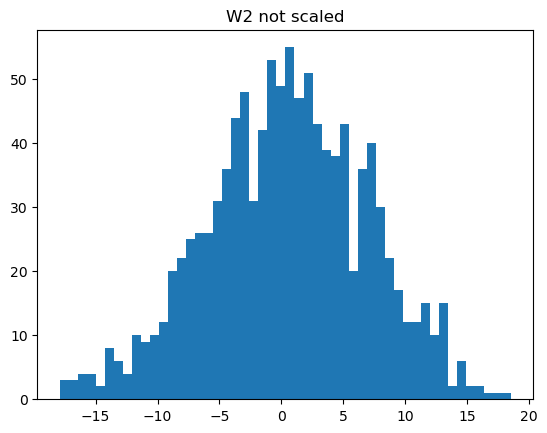

In [213]:
W2_bad = torch.randn(n_hidden, vocab_size)
logits_bad = (torch.tanh(emb @ W1 + b1)) @ W2_bad + b2
plt.hist(logits_bad.view(-1).detach(), bins=50)
plt.title("W2 not scaled")
plt.show()

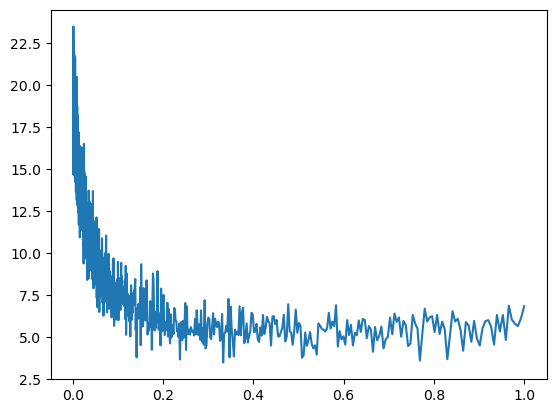

In [177]:
plt.plot(lre,lossi)

0.1 seems to be a good choice for lr

In [188]:
n_embd = 10
n_hidden = 100
C = torch.randn(vocab_size,n_embd)
W1 = torch.randn((n_embd*context_size),n_hidden)
b1 = torch.randn(n_hidden)
W2 = torch.randn(n_hidden,vocab_size)
b2 = torch.randn(vocab_size)

parameters = [C,W1,b1,W2,b2]

In [189]:
for p in parameters:
    p.requires_grad = True

(array([1130.,   79.,   47.,   34.,   24.,   17.,   12.,   20.,   21.,
          12.,   15.,   18.,   11.,   12.,    9.,   10.,   10.,   14.,
           7.,   11.,    8.,    8.,    8.,    7.,    7.,   12.,    6.,
          11.,    7.,   11.,    7.,    8.,    5.,   13.,    4.,   13.,
          16.,   14.,   11.,    9.,   19.,   19.,   17.,   14.,   27.,
          30.,   39.,   38.,   77., 1222.]),
 array([-1.        , -0.95999998, -0.92000002, -0.88      , -0.84000003,
        -0.80000001, -0.75999999, -0.72000003, -0.68000001, -0.63999999,
        -0.60000002, -0.56      , -0.51999998, -0.48000002, -0.44      ,
        -0.40000004, -0.36000001, -0.31999999, -0.28000003, -0.24000001,
        -0.20000005, -0.16000003, -0.12      , -0.08000004, -0.04000002,
         0.        ,  0.03999996,  0.07999992,  0.12      ,  0.15999997,
         0.19999993,  0.24000001,  0.27999997,  0.31999993,  0.36000001,
         0.39999998,  0.43999994,  0.48000002,  0.51999998,  0.55999994,
         0.59999

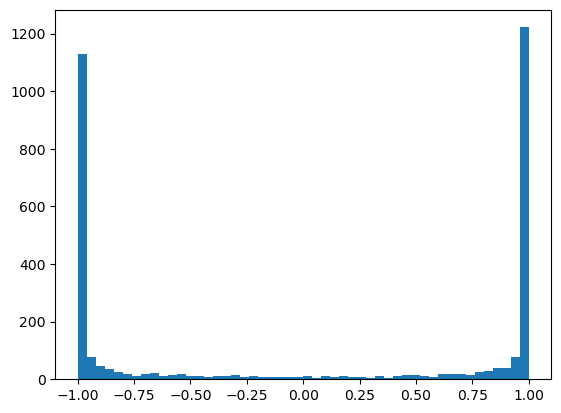

In [190]:
ix = torch.randint(0, Xtr.shape[0], (32,))
emb = C[Xtr[ix]]
emb = emb.view(-1, n_embd * context_size)
hpre = emb @ W1 + b1
h = torch.tanh(hpre)
plt.hist(h.view(-1).detach(), bins=50)

In [191]:
step_size = 1000

for i in range(step_size):
    ix = torch.randint(0,Xtr.shape[0],(32,))
    emb = C[Xtr[ix]]
    emb = emb.view(Xtr[ix].shape[0],-1)
    hpre = emb @ W1 + b1
    h = torch.tanh(hpre)
    logits = h @ W2 + b2

    loss = F.cross_entropy(logits,Ytr[ix])

    if i % 100 == 0:
        print(loss.item())

    for p in parameters:
        p.grad = None

    loss.backward()

    for p in parameters:
        p.data += -0.1 * p.grad
    

19.860855102539062
9.518681526184082
6.2021484375
3.5669493675231934
4.742044448852539
4.395617961883545
3.830458641052246
4.134382247924805
5.363800525665283
4.3353352546691895


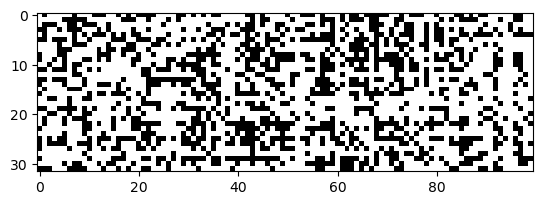

In [192]:
plt.imshow(h.abs() > 0.99, cmap='gray')

In [226]:
n_embd = 10
n_hidden = 100
C = torch.randn(vocab_size,n_embd)
W1 = torch.randn((n_embd*context_size),n_hidden) * 0.01
b1 = torch.randn(n_hidden) * 0
W2 = torch.randn(n_hidden,vocab_size) * 0.01
b2 = torch.randn(vocab_size) * 0

parameters = [C,W1,b1,W2,b2]

for p in parameters:
    p.requires_grad = True

(array([  1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,   1.,
          4.,   7.,   9.,   8.,  16.,  19.,  20.,  27.,  38.,  65.,  71.,
         79., 110., 169., 158., 177., 187., 233., 210., 219., 209., 189.,
        178., 159., 132., 127., 101.,  81.,  54.,  44.,  34.,  18.,  11.,
         13.,  10.,   4.,   2.,   2.,   3.]),
 array([-0.31446785, -0.30391851, -0.29336914, -0.28281981, -0.27227044,
        -0.2617211 , -0.25117177, -0.24062242, -0.23007306, -0.21952371,
        -0.20897436, -0.19842502, -0.18787567, -0.17732632, -0.16677698,
        -0.15622763, -0.14567828, -0.13512893, -0.12457958, -0.11403024,
        -0.10348089, -0.09293154, -0.0823822 , -0.07183285, -0.0612835 ,
        -0.05073416, -0.0401848 , -0.02963546, -0.01908612, -0.00853676,
         0.00201258,  0.01256195,  0.02311128,  0.03366062,  0.04420999,
         0.05475932,  0.06530869,  0.07585803,  0.08640736,  0.09695673,
         0.10750607,  0.1180554 ,  0.12860477,  0.13915411,  0.14970344,
 

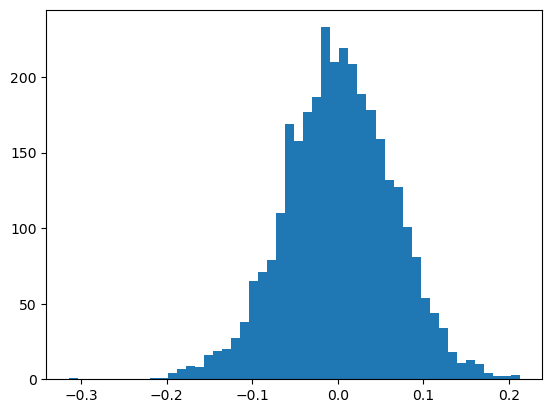

In [227]:
ix = torch.randint(0, Xtr.shape[0], (32,))
emb = C[Xtr[ix]]
emb = emb.view(-1, n_embd * context_size)
hpre = emb @ W1 + b1
h = torch.tanh(hpre)
plt.hist(h.view(-1).detach(), bins=50)

In [228]:
step_size = 20000
lossi = []

for i in range(step_size):
    ix = torch.randint(0,Xtr.shape[0],(32,))
    emb = C[Xtr[ix]]
    emb = emb.view(Xtr[ix].shape[0],-1)
    hpre = emb @ W1 + b1
    h = torch.tanh(hpre)
    logits = h @ W2 + b2

    loss = F.cross_entropy(logits,Ytr[ix])

    if i % 1000 == 0:
        print(loss.item())

    for p in parameters:
        p.grad = None

    loss.backward()

    for p in parameters:
        p.data += -0.1 * p.grad

    lossi.append(loss.item())
    

3.5274739265441895
2.3843517303466797
2.5045626163482666
2.3257253170013428
2.3957905769348145
2.479391098022461
2.2112627029418945
2.1015191078186035
2.5503299236297607
2.5136795043945312
2.002654552459717
2.473137378692627
2.1750481128692627
1.8513604402542114
1.8054512739181519
1.8419692516326904
2.104320764541626
1.9664866924285889
2.191009283065796
2.011441707611084


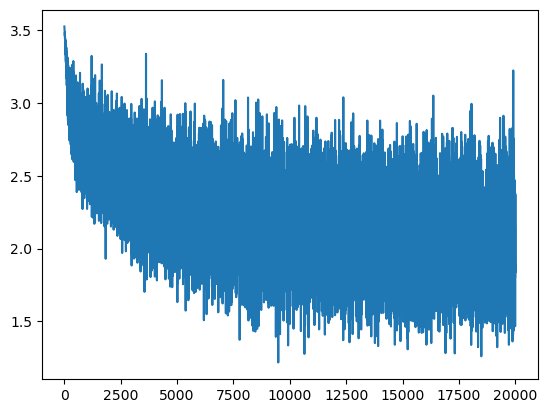

In [229]:
plt.plot(lossi)

In [230]:
emb = C[Xtr]
emb = emb.view(-1, n_embd * context_size)
h = torch.tanh(emb @ W1 + b1)
logits = h @ W2 + b2
print("train",F.cross_entropy(logits, Ytr).item())

train 2.0560672283172607


In [231]:
emb = C[Xdev]
emb = emb.view(-1, n_embd * context_size)
h = torch.tanh(emb @ W1 + b1)
logits = h @ W2 + b2
print("dev",F.cross_entropy(logits, Ydev).item())

dev 2.11830472946167


Implementing batchnorm

In [248]:
n_embd = 10
n_hidden = 100
C = torch.randn(vocab_size,n_embd)
W1 = torch.randn((n_embd*context_size),n_hidden) * 0.01
b1 = torch.randn(n_hidden) * 0
W2 = torch.randn(n_hidden,vocab_size) * 0.01
b2 = torch.randn(vocab_size) * 0
gamma = torch.randn(1,n_hidden)
beta = torch.randn(1,n_hidden)
parameters = [C,W1,b1,W2,b2,gamma,beta]
running_mean = torch.zeros(1,n_hidden)
running_std = torch.ones(1,n_hidden)


for p in parameters:
    p.requires_grad = True

In [249]:
step_size = 200000
lossi = []

for i in range(step_size):
    ix = torch.randint(0,Xtr.shape[0],(32,))
    emb = C[Xtr[ix]]
    emb = emb.view(Xtr[ix].shape[0],-1)
    hpre = emb @ W1 + b1
    hpmean = hpre.mean(0,keepdim=True)
    hpstd = hpre.std(0,keepdim=True)
    with torch.no_grad():
        running_mean = 0.999 * running_mean + 0.001 * hpmean
        running_std = 0.999 * running_std + 0.001 * hpstd
    hnrm = gamma * ((hpre-hpmean)/(hpstd + 1e-5 )) + beta 
    h = torch.tanh(hnrm)
    logits = h @ W2 + b2

    loss = F.cross_entropy(logits,Ytr[ix])

    if i % 10000 == 0:
        print(loss.item())

    for p in parameters:
        p.grad = None

    loss.backward()
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    lossi.append(loss.item())
    

3.5231475830078125
2.0910356044769287
2.4344024658203125
2.2087810039520264
1.9397497177124023
2.5314712524414062
2.29465389251709
1.9480297565460205
1.7094627618789673
2.630632162094116
2.29848313331604
2.0600497722625732
2.1894044876098633
1.9079605340957642
2.1820037364959717
1.6550061702728271
1.9625062942504883
2.3899600505828857
2.103553533554077
2.3791980743408203


In [250]:
emb = C[Xtr]
emb = emb.view(-1, n_embd * context_size)
hpre = emb @ W1 + b1
hnrm = gamma * ((hpre-running_mean)/(running_std + 1e-5 )) + beta 
h = torch.tanh(hnrm)
logits = h @ W2 + b2
loss = F.cross_entropy(logits,Ytr).item()
print("train",loss)

train 1.9432964324951172


In [252]:
emb = C[Xdev]
emb = emb.view(-1, n_embd * context_size)
hpre = emb @ W1 + b1
hnrm = gamma * ((hpre-running_mean)/(running_std + 1e-5 )) + beta 
h = torch.tanh(hnrm)
logits = h @ W2 + b2
loss = F.cross_entropy(logits,Ydev).item()
print("dev",loss)

dev 2.0040173530578613


In [261]:
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * context_size

    while True:
        emb = C[torch.tensor([context])]
        emb = emb.view(emb.shape[0],-1)
        hpre = emb @ W1 + b1
        hpre = gamma * ((hpre - running_mean)/ running_std + 1e-5) + beta
        h = torch.tanh(hpre)
        logits = h @ W2 + b2

        probs = F.softmax(logits,dim=1)
        ix = torch.multinomial(probs,num_samples=1,generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break

    print(''.join(itos[i] for i in out if itos[i] != '~'))

btch
oal
b pal tel
industructionedance
dia
lino
moilpelaf ins
dureipmenternatuela su  heure met services
net
span solutionations
pack yxsuro gswatio
infrasank
ing
detal
funda ondia
phatagatics
me
foshasem and chemo
aumsuprojies
zance


In [269]:
class Linear:
    def __init__(self,fan_in,fan_out,bias=True):
        self.weights = torch.randn(fan_in,fan_out) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self,x):
        self.out = x @ self.weights
        if self.bias is not None:
            self.out += self.bias
        return self.out 

    def parameters(self):
        return [self.weights] + ([] if self.bias is None else [self.bias])


class BatchNorm1d:
    def __init__(self,n_features,eps = 1e-5,momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.gamma = torch.ones(n_features)
        self.beta = torch.zeros(n_features)

        self.running_mean = torch.zeros(n_features)
        self.running_var = torch.ones(n_features)
        self.training = True

    def __call__(self,x):
        if self.training:
            xmean = x.mean(0,keepdim=True)
            xvar = x.var(0,keepdim=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var

        xhat = (x-xmean)/ torch.sqrt(xvar+self.eps)
        self.out = self.gamma * xhat + self.beta
        
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar

        return self.out

    def parameters(self):
        return [self.gamma,self.beta]

class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []
        

In [270]:
g = torch.Generator().manual_seed(2147483647)
n_embd = 10
n_hidden = 100
vocab_size = len(stoi)

C = torch.randn(vocab_size,n_embd, generator = g)

layers = [
    Linear((n_embd*context_size),n_hidden,bias=False),BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden,n_hidden,bias=False),BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden,n_hidden,bias=False),BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden,n_hidden,bias=False),BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden,n_hidden,bias=False),BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden,vocab_size,bias=False),BatchNorm1d(vocab_size),
]

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))
for p in parameters:
  p.requires_grad = True

47808


In [271]:
steps = 200000
batch_size = 32

for i in range(steps):

    ix = torch.randint(0,Xtr.shape[0],(batch_size,))
    Xb, Yb = Xtr[ix] , Ytr[ix]

    emb = C[Xb]
    x = emb.view(emb.shape[0],-1)

    for layer in layers:
        x = layer(x)

    loss = F.cross_entropy(x,Yb)

    for p in parameters:
        p.grad = None

    loss.backward()

    lr = 0.1 if i < 150000 else 0.01 
    for p in parameters:
        p.data += -lr * p.grad

    if i % 10000 == 0: 
        print(f'{i:7d}/{steps:7d}: {loss.item():.4f}')


      0/ 200000: 4.1280
  10000/ 200000: 2.5157
  20000/ 200000: 1.9205
  30000/ 200000: 1.7590
  40000/ 200000: 1.7392
  50000/ 200000: 2.2924
  60000/ 200000: 1.3536
  70000/ 200000: 1.6030
  80000/ 200000: 1.8384
  90000/ 200000: 1.9313
 100000/ 200000: 1.2949
 110000/ 200000: 1.6154
 120000/ 200000: 1.8732
 130000/ 200000: 1.7956
 140000/ 200000: 2.1347
 150000/ 200000: 1.8194
 160000/ 200000: 1.6871
 170000/ 200000: 1.4951
 180000/ 200000: 1.8051
 190000/ 200000: 2.0489


In [272]:
for layer in layers:
    layer.training = False

In [277]:
emb = C[Xtr]
x = emb.view(Xtr.shape[0],-1)

for layer in layers:
    x = layer(x)

loss = F.cross_entropy(x,Ytr)

print("train",loss.item())

train 1.7032513618469238


In [275]:
emb = C[Xdev]
x = emb.view(Xdev.shape[0],-1)

for layer in layers:
    x = layer(x)

loss = F.cross_entropy(x,Ydev)

print("dev",loss.item())

dev 1.8418805599212646


In [276]:
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * context_size

    while True:
        emb = C[torch.tensor([context])]
        x = emb.view(emb.shape[0],-1)

        for layer in layers:
            x = layer(x)

        probs = F.softmax(x,dim = 1)

        ix = torch.multinomial(probs,num_samples = 1,generator=g).item()

        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break

    print(''.join(itos[i] for i in out if itos[i] != '~'))

bsc
toans
 logies
mindustruction devconnectl ener infota
india
freighting
dav elecom  healty
ram solutics
governation
piramal era autoyotive 
swatio
interpriseing
delhe
futual seidernations
cing
hims
essi autocg bollo solution nic science capidkong tech india
motiversity  cons
thill hosphar indrank
exporate engineers industries
